In [1]:
import pandas as pd
import os.path as op
import numpy as np
from os import listdir
import matplotlib.pyplot as plt

bids_folder = '/Volumes/mrenkeED/data/ds-stressrisk'
bids_folder_behav ='/Users/mrenke/data/ds-stressrisk'
subFolders = [f for f in listdir(bids_folder) if f[0:3] == 'sub']

decod_dir = op.join(bids_folder, 'derivatives', 'decoded_pdfs.volume.svoxels.ses1-en_ses2-de.denoise.retroicor' )
sub='01'



In [2]:
from stress_risk.utils.data import get_data

df = get_data(bids_folder = bids_folder_behav)
df = df[df['session'] == 2]

/Users/mrenke/mambaforge/envs/behav_fit2/lib/python3.10/site-packages/nilearn/glm/__init__.py:55: FutureWarning: The nilearn.glm module is experimental. It may change in any future release of Nilearn.
  warn('The nilearn.glm module is experimental. '
/Users/mrenke/mambaforge/envs/behav_fit2/lib/python3.10/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
import os
import re

def get_decod(subject, decod_dir):
    #mask='NPC_R'

    fils = os.listdir(op.join(decod_dir,f'{subject}','func'))
    for f in fils:
        if re.match(f'{subject}_ses1-en_ses2-de', f):
            file = f

    #subject = f'{sub:02d}'
    pdf = op.join(decod_dir,f'{subject}','func', file)
    pdf = pd.read_csv(pdf, sep='\t', index_col=[0])
    pdf = pdf.set_index('trial_nr')
    pdf.columns = pdf.columns.astype(float)
    pdf = pdf.loc[:, np.log(5):np.log(28*4)]

    E = (pdf*pdf.columns.values[np.newaxis, :] / pdf.sum(1).values[:, np.newaxis]).sum(1)
    E = pd.DataFrame(E)
    E = E.rename(columns={0:'E'})
    pdf /= np.trapz(pdf, pdf.columns.astype(float))[:, np.newaxis] #normalizing

    E['sd'] = np.trapz(np.abs(E.values - pdf.columns.astype(float).values[np.newaxis, :]) * pdf, pdf.columns, axis=1)
    E['subject'] = int(subject[4:])
    E = E.reset_index().set_index(['subject','trial_nr'])
    
    return E


In [4]:
subject = subFolders[1]

fils = os.listdir(op.join(decod_dir,f'{subject}','func'))
for f in fils:
    if re.match(f'{subject}_ses1-en_ses2-de', f):
        file = f

#subject = f'{sub:02d}'
pdf = op.join(decod_dir,f'{subject}','func', file)
pdf = pd.read_csv(pdf, sep='\t', index_col=[0])
pdf = pdf.set_index('trial_nr')
pdf.columns = pdf.columns.astype(float)

In [5]:
#Es = [get_decod(subject, decod_dir) for subject in subFolders]

Es = pd.DataFrame()

for subject in subFolders:
    try:
        E = get_decod(subject, decod_dir)
        Es = pd.concat([Es, E])
    except:
        print(f'{subject} makes problems')


In [21]:
temp = Es.join(df.reset_index().set_index(['subject','trial_nr'])[['n1', 'group', 'risky_first']])
temp['log_n1'] = np.log(temp['n1'])

temp.to_csv('/Users/mrenke/data/ds-stressrisk/interim_sum_data/across_ses_decodedE.csv')


Text(0.5, 1.0, 'p = 0.039')

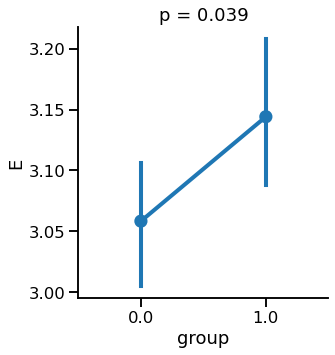

In [52]:
import seaborn as sns
import pingouin
import matplotlib.pyplot as plt

sns.set_context('talk')

mean_E = temp.groupby(['subject', 'group'])[['E']].mean()
sns.catplot(data=mean_E.reset_index(), x='group', y='E',kind='point')

an = pingouin.anova(data=mean_E.reset_index(),dv='E', between='group')
p_val = an['p-unc'][0].round(3)
plt.title(f'p = {p_val}')


Text(0.5, 1.0, 'only save: p = 0.004 \n only risky: p = 0.254 ')

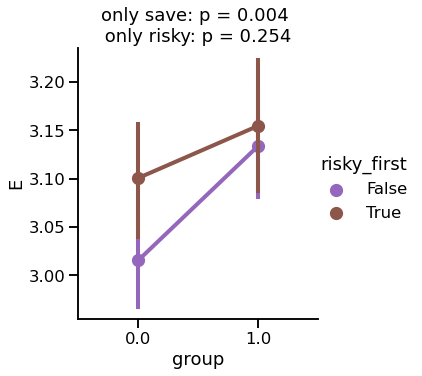

In [62]:
import seaborn as sns
import pingouin

mean_E = temp.groupby(['subject', 'group', 'risky_first'])[['E']].mean()
sns.catplot(data=mean_E.reset_index(), x='group', y='E',kind='point', hue='risky_first', palette=sns.color_palette()[4:], errorbar = 'se')

p_val_safe = pingouin.anova(data=mean_E.xs(False, 0,'risky_first' ).reset_index(),dv='E', between='group')
p_val_risky = pingouin.anova(data=mean_E.xs(True, 0,'risky_first' ).reset_index(),dv='E', between='group')

p_val_safe = p_val_safe['p-unc'][0].round(3)
p_val_risky = p_val_risky['p-unc'][0].round(3)
plt.title(f'only save: p = {p_val_safe} \n only risky: p = {p_val_risky} ')



Text(0.5, 1.0, 'p = 0.244')

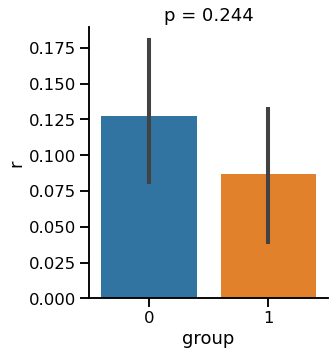

In [64]:
import seaborn as sns
from stress_risk.utils.data import add_cond2df
import pingouin

r = temp.groupby(['subject']).apply(lambda d: pingouin.corr(d['E'], d['log_n1']))

r = add_cond2df(r)

sns.catplot(data=r.reset_index(), x='group', y='r', kind='bar' ) #kind='bar', 
an = pingouin.anova(data=r,dv='r', between='group')
p_val = an['p-unc'][0].round(3)
plt.title(f'p = {p_val}')


Text(0.5, 1.0, 'only save: p = 0.842 \n only risky: p = 0.463 ')

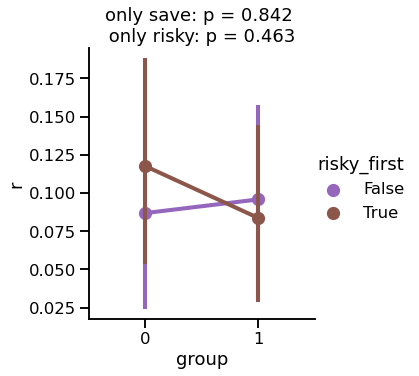

In [72]:
import seaborn as sns
from stress_risk.utils.data import add_cond2df
import pingouin

r = temp.groupby(['subject', 'risky_first']).apply(lambda d: pingouin.corr(d['E'], d['log_n1']))

r = add_cond2df(r)

sns.catplot(data=r.reset_index(), x='group', y='r',hue='risky_first', kind='point',palette=sns.color_palette()[4:], errorbar = 'se') #kind='bar', 
pingouin.anova(data=r,dv='r', between='group')



<AxesSubplot: xlabel='log_n1', ylabel='E'>

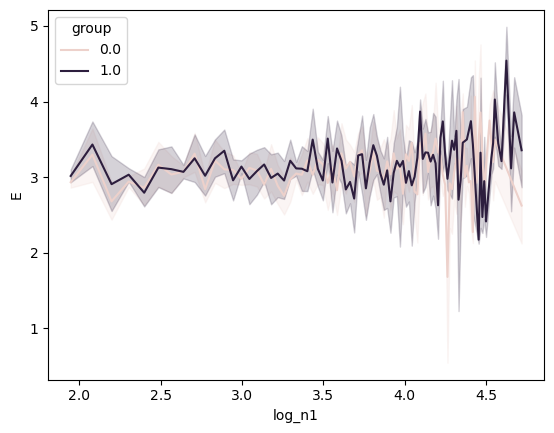

In [82]:
import seaborn as sns
sns.lineplot(temp, x='log_n1', y='E', hue='group')

In [ ]:
sns.catplot(x='group', y='r', data=r...)

In [1]:
import pingouin

/Users/mrenke/mambaforge/envs/numrefields/lib/python3.10/site-packages/outdated/utils.py:14: OutdatedPackageWarning: The package outdated is out of date. Your version is 0.2.1, the latest is 0.2.2.
Set the environment variable OUTDATED_IGNORE=1 to disable these warnings.
  return warn(
/Users/mrenke/mambaforge/envs/numrefields/lib/python3.10/site-packages/outdated/utils.py:14: OutdatedPackageWarning: The package pingouin is out of date. Your version is 0.5.2, the latest is 0.5.3.
Set the environment variable OUTDATED_IGNORE=1 to disable these warnings.
  return warn(


In [14]:
# r = ...


# sns.catplot(x='group', y='r', data=r...)

temp.reset_index().dropna()

#pingouin.anova(dv='r', )

,subject,trial_nr,E,sd,n1,group,risky_first,log_n1
0,1,1,3.122084,0.101011,28.0,0.0,False,3.332205
1,1,2,2.320762,0.111215,14.0,0.0,False,2.639057
2,1,3,2.327734,0.407480,20.0,0.0,False,2.995732
3,1,4,2.627432,0.244388,20.0,0.0,False,2.995732
4,1,5,3.416933,0.215128,28.0,0.0,False,3.332205
...,...,...,...,...,...,...,...,...
5995,61,116,3.944864,0.526355,39.0,0.0,True,3.663562
5996,61,117,3.905492,0.351879,43.0,0.0,True,3.761200
5997,61,118,2.644663,0.140344,34.0,0.0,True,3.526361
5998,61,119,2.436559,0.227761,34.0,0.0,True,3.526361


In [ ]:
import bambi
target_folder =op.join(bids_folder_behav, 'derivatives', 'hierachical_models')

model = bambi.Model('E ~ log_n1*group*risky_first +  (log_n1*risky_first|subject)', data=temp.reset_index().dropna())
traces = model.fit(init='adapt_diag', target_accept=0.9, draws=1000, tune=1000)

import arviz as az
az.to_netcdf(traces, op.join(target_folder, f'across_session_decoding_bambi_1.netcdf'))

In [20]:
target_folder =op.join(bids_folder_behav, 'derivatives', 'hierachical_models')
az.to_netcdf(traces, op.join(target_folder, f'across_session_decoding_bambi_1.netcdf'))

'/Users/mrenke/data/ds-stressrisk/derivatives/hierachical_models/across_session_decoding_bambi_1.netcdf'

In [ ]:
sns.lineplot(x='log_n', y='E', hue='group')

In [19]:
traces


Inference data with groups:
	> posterior
	> log_likelihood
	> sample_stats
	> observed_data